# Random walks on a 3-dimensional lattice
Alessio Martini

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def random_walk(dimension, steps, walkers):
    positions = np.zeros((walkers, steps+1, dimension), dtype=int) # una lista 3d: simulazione, step, asse
    returns_to_origin = np.zeros(walkers, dtype=bool) # se la simulazione e ripassata dall'origine

    for i in range(steps):
        # Genera direzioni casuali per ogni walker
        moves = np.random.randint(0, dimension, size=walkers) # sceglie la direzione in cui spostarsi
        directions = np.random.choice([-1, 1], size=walkers) # sceglie se avanti o indietro in quella direzione
        
        # Aggiorna le posizioni
        positions[np.arange(walkers), i+1] = positions[np.arange(walkers), i]
        positions[np.arange(walkers), i+1, moves] += directions
        
        # Controlla se tornano all'origine
        for sim in range(walkers):
            if np.all(positions[sim,i+1] == 0):
                returns_to_origin[sim] = True
                #return positions, returns_to_origin

    return positions, returns_to_origin

# parameters of the simulation:

In [5]:
# Parametri generali
walkers = 10000              # Numero di camminatori
steps_list = [10, 50, 100, 200, 500, 1000]  # Lista dei passi
dimension = 3                # Numero di dimensioni (3D)

fractions = []
for steps in steps_list:
    positions, returns_to_origin = random_walk(dimension, steps, walkers)
    fraction = np.sum(returns_to_origin) / walkers
    fractions.append(fraction)
    print(f"N={steps}, fraction passed throug the origin: {fraction:.3f}")

N=10, fraction passed throug the origin: 0.255
N=50, fraction passed throug the origin: 0.307
N=100, fraction passed throug the origin: 0.308
N=200, fraction passed throug the origin: 0.314
N=500, fraction passed throug the origin: 0.325
N=1000, fraction passed throug the origin: 0.334


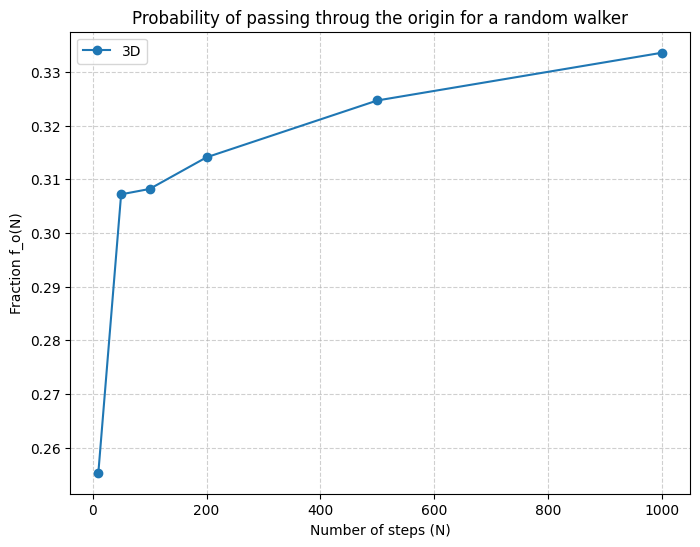

In [6]:
# Plot dei risultati
plt.figure(figsize=(8, 6))
plt.plot(steps_list, fractions, 'o-', label="3D")
#plt.xscale('log')
plt.xlabel("Number of steps (N)")
plt.ylabel("Fraction f_o(N)")
plt.title("Probability of passing throug the origin for a random walker")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

This graph isn't faithful in its last point because the number of walkers (10000) is just one order of magnitude larger than the number of steps (1000). This implies than the simulation is not statistical convergent, it has big variance.

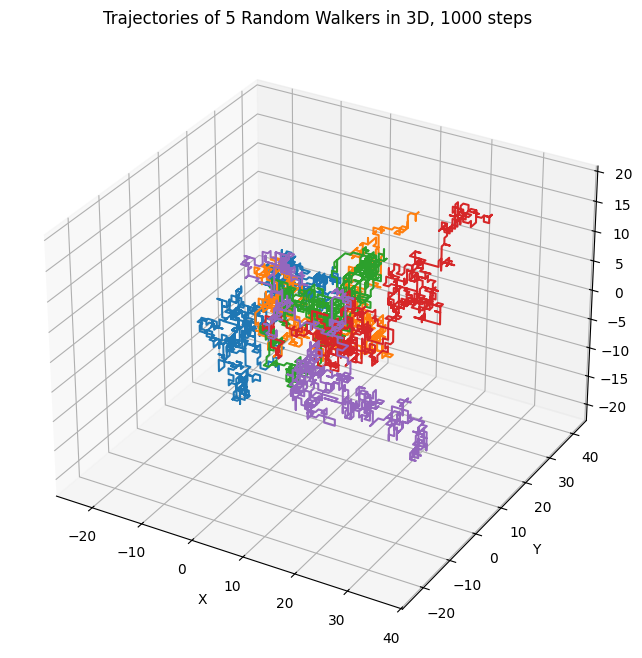

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for i in range(5):
    ax.plot(positions[i,:,0],positions[i,:,1],positions[i,:,2])

# Configurazione dell'asse
ax.set_title("Trajectories of 5 Random Walkers in 3D, 1000 steps")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# Various Dimensions

Actually we expect that for 1D and 2D the probability approach 1 as the number of steps increases, while for dimensions >= 3D it doesn't. Unfortunately, we can't appreciate fully the convergence to 1 of the first two simulations because of computational limits.

# parameters:
The numbers of walkers for each N is 2000.

In [8]:
# Estensione a higher dimensions
dimensions = [1,2,3, 4, 5]
results = []

# Parametri generali
walkers = 2000              # Numero di camminatori
steps_list = [2,4,8,16,32,64,128]  # Lista dei passi
#dimension = 3                # Numero di dimensioni (3D)

for dimension in dimensions:
    fractions = []
    for steps in steps_list:
        positions, returns_to_origin = random_walk(dimension, steps, walkers)
        fraction = np.sum(returns_to_origin) / walkers
        fractions.append(fraction)
        #print(f"N={steps}, frazione di ritorno: {fraction:.3f}")
    
    # Plot dei risultati
    results.append(fractions) 

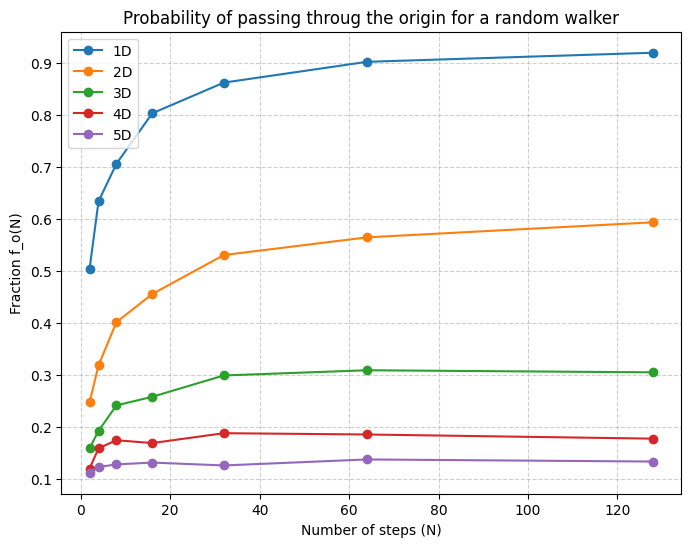

In [9]:
plt.figure(figsize=(8, 6))

for i,fractions in enumerate(results):
    plt.plot(steps_list, fractions, 'o-', label=f"{i+1}D")
    
#plt.xscale('log')
plt.xlabel("Number of steps (N)")
plt.ylabel("Fraction f_o(N)")
plt.title("Probability of passing throug the origin for a random walker")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

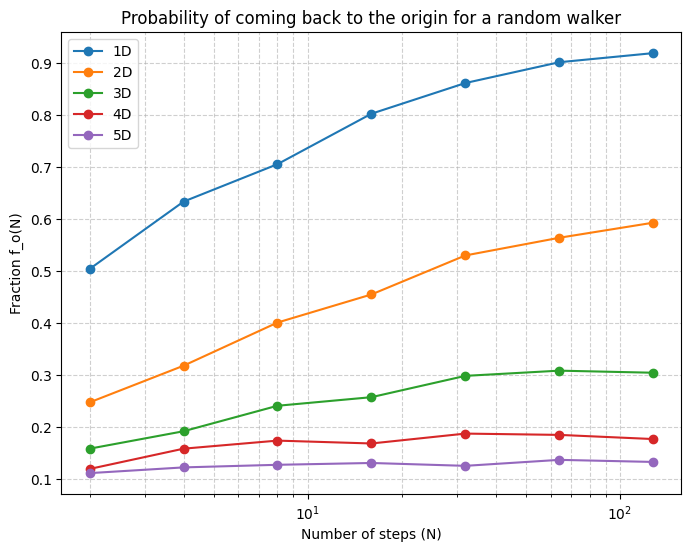

In [10]:
plt.figure(figsize=(8, 6))

for i,fractions in enumerate(results):
    plt.plot(steps_list, fractions, 'o-', label=f"{i+1}D")
    
plt.xscale('log')
plt.xlabel("Number of steps (N)")
plt.ylabel("Fraction f_o(N)")
plt.title("Probability of coming back to the origin for a random walker")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# Fractal Dimension

From the literature, $d_f$ should be smaller than the dimension (at least for dimension greater or equal to 2). Here i found out that the behaviour of the system is different only in dimension 1, while all the others behave similarly.
Unfortunately i've found no references to compare my results to.

In [30]:
def random_walk_distances(num_walkers, dimension, max_steps):
    distances = np.zeros(max_steps)  # Array per salvare la distanza media per ogni step
     
    for _ in range(num_walkers):
        position = np.zeros(dimension)  # Ogni walker parte dall'origine
        
        for step in range(1,max_steps):
            axis = np.random.randint(0, dimension)  # Scegli un asse casuale
            direction = np.random.choice([-1, 1])  # Scegli direzione (+1 o -1)
            position[axis] += direction  # Aggiorna la posizione
            
            distances[step] += np.linalg.norm(position)  # Calcola distanza dall'origine
    
    distances /= num_walkers  # Media sulle traiettorie
    return distances.tolist()

In [31]:
# Parametri
dimensions = [1,2,3,4,5,6]               # Dimensioni del reticolo
walkers = 2000               # Numero di camminatori
max_steps = 100           # Numero massimo di passi per walker
#radius = list(range(1, 5)) # Raggi target (1, 2, ..., 20)

average_radius = [] # average radius for 2000 walkers doing N steps: R(N)

for dimension in dimensions:
    # Esegui la simulazione
    results = random_walk_distances(walkers, dimension, max_steps)
    # Calcola la media degli step per ciascun raggio
    average_radius.append(results)

In [32]:
from scipy.optimize import curve_fit

# Define the Gaussian function
def Power_law(x, A,B):
    y = A*np.power(x, B)
    return y

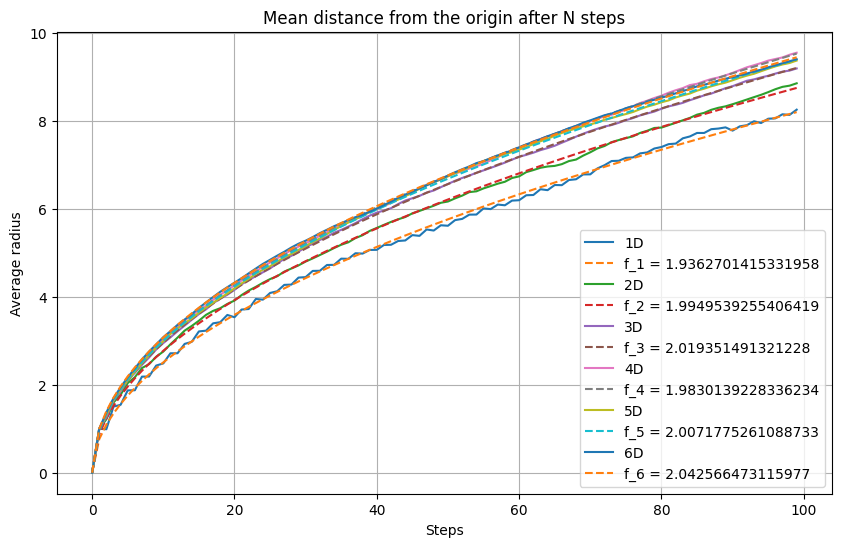

In [36]:
plt.figure(figsize=(10, 6))

for i,dimension in enumerate(dimensions):
    # Plot dei risultati
    plt.plot([*range(max_steps)],average_radius[i], label=f"{dimension}D")
    
    parameters, covariance = curve_fit(Power_law, [*range(max_steps)], average_radius[i])
    fit_A = parameters[0]
    fit_B = parameters[1]
    fit_y = Power_law([*range(max_steps)], fit_A, fit_B)
    plt.plot([*range(max_steps)], fit_y, '--', label=f"f_{dimension} = {1/fit_B}")
    
    
plt.ylabel("Average radius")
plt.xlabel("Steps")
plt.title(f"Mean distance from the origin after N steps")
plt.grid(True)
plt.legend()
plt.show()

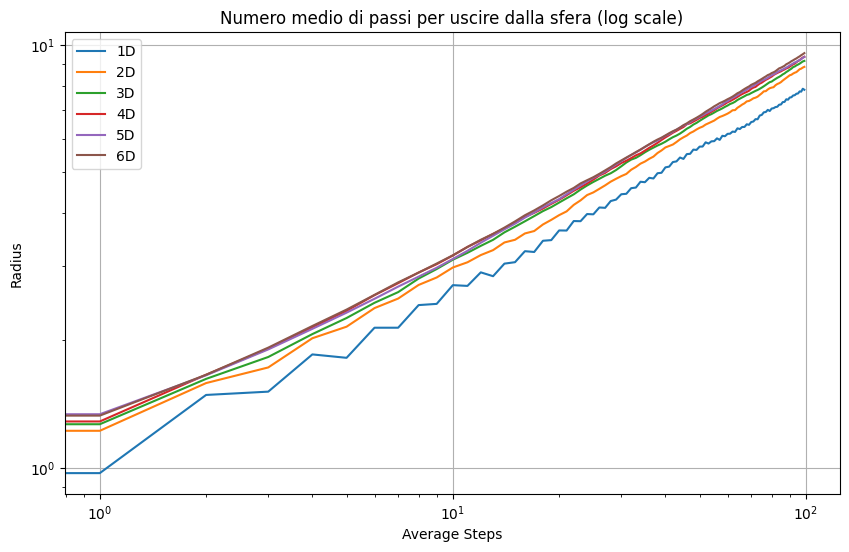

In [18]:
plt.figure(figsize=(10, 6))

for i,dimension in enumerate(dimensions):
    # Plot dei risultati
    plt.plot([*range(max_steps)],average_radius[i], label=f"{dimension}D")
    
plt.ylabel("Radius")
plt.xlabel("Average Steps")
plt.xscale("log")
plt.yscale("log")
plt.title(f"Numero medio di passi per uscire dalla sfera (log scale)")
plt.grid(True)
plt.legend()
plt.show()